# Тема 8. Indoor Objects Detection (YOLOv9s)

Детекція об'єктів у приміщенні на датасеті [Indoor Objects Detection](https://www.kaggle.com/datasets/thepbordin/indoor-object-detection).


In [1]:
!pip install --upgrade ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.5 MB/s eta 0:00:00


## Набір даних

Формат розмітки YOLO: `[class_id, center_x, center_y, width, height]` (нормалізовані координати 0–1).

Класи (порядок як у `data.yaml` датасету):

| id | class |
|----|--------|
| 0 | door |
| 1 | cabinetDoor |
| 2 | refrigeratorDoor |
| 3 | window |
| 4 | chair |
| 5 | table |
| 6 | cabinet |
| 7 | couch |
| 8 | openedDoor |
| 9 | pole |

Спліти `train` / `valid` / `test` уже задані в датасеті. Файл `data.yaml` у датасеті містить Colab-шляхи (`/content/data/...`), тому нижче створюємо новий YAML для Kaggle.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import glob
import random
import shutil
import yaml

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import cv2

import torch
from ultralytics import YOLO
from IPython.display import display

%matplotlib inline

!wandb disabled

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}:", torch.cuda.get_device_name(i))


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
wandb: Updated settings file /kaggle/working/wandb/settings
W&B disabled.
CUDA available: True
GPU count: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [3]:
class CFG:
    DEBUG = False  # True — швидка перевірка пайплайна
    FRACTION = 0.05 if DEBUG else 1.0
    SEED = 42

    CLASSES = [
        "door",
        "cabinetDoor",
        "refrigeratorDoor",
        "window",
        "chair",
        "table",
        "cabinet",
        "couch",
        "openedDoor",
        "pole",
    ]
    NUM_CLASSES_TO_TRAIN = len(CLASSES)

    EPOCHS = 3 if DEBUG else 50
    BATCH_SIZE = 8 if DEBUG else 32  # ~16 на кожну T4
    IMGSZ = 640

    BASE_MODEL = "yolov9s"
    BASE_MODEL_WEIGHTS = f"{BASE_MODEL}.pt"
    EXP_NAME = f"indoor_{EPOCHS}_epochs"

    OPTIMIZER = "auto"
    LR = 1e-3
    LR_FACTOR = 0.01
    WEIGHT_DECAY = 5e-4
    DROPOUT = 0.0
    PATIENCE = 15
    PROFILE = False
    LABEL_SMOOTHING = 0.0

    CUSTOM_DATASET_DIR = "/kaggle/input/datasets/thepbordin/indoor-object-detection"
    OUTPUT_DIR = "/kaggle/working/"

    N_GPU = torch.cuda.device_count()
    DEVICE = [0, 1] if N_GPU >= 2 else ([0] if N_GPU == 1 else "cpu")


random.seed(CFG.SEED)
np.random.seed(CFG.SEED)

print("Device:", CFG.DEVICE)
print("Epochs:", CFG.EPOCHS)
print("Batch:", CFG.BATCH_SIZE)
print("Model:", CFG.BASE_MODEL_WEIGHTS)


Device: [0, 1]
Epochs: 50
Batch: 32
Model: yolov9s.pt


Створення `data.yaml` зі шляхами Kaggle.


In [4]:
dict_file = {
    "train": os.path.join(CFG.CUSTOM_DATASET_DIR, "train"),
    "val": os.path.join(CFG.CUSTOM_DATASET_DIR, "valid"),
    "test": os.path.join(CFG.CUSTOM_DATASET_DIR, "test"),
    "nc": CFG.NUM_CLASSES_TO_TRAIN,
    "names": CFG.CLASSES,
}

yaml_path = os.path.join(CFG.OUTPUT_DIR, "data.yaml")
with open(yaml_path, "w+") as file:
    yaml.dump(dict_file, file, sort_keys=False, allow_unicode=True)


In [5]:
def read_yaml_file(file_path):
    with open(file_path, "r") as file:
        try:
            return yaml.safe_load(file)
        except yaml.YAMLError as e:
            print("Error reading YAML:", e)
            return None


def print_yaml_data(data):
    print(yaml.dump(data, default_style=False, allow_unicode=True))


yaml_data = read_yaml_file(yaml_path)
if yaml_data:
    print_yaml_data(yaml_data)


names:
- door
- cabinetDoor
- refrigeratorDoor
- window
- chair
- table
- cabinet
- couch
- openedDoor
- pole
nc: 10
test: /kaggle/input/datasets/thepbordin/indoor-object-detection/test
train: /kaggle/input/datasets/thepbordin/indoor-object-detection/train
val: /kaggle/input/datasets/thepbordin/indoor-object-detection/valid



## Знайомство з даними


Example: /kaggle/input/datasets/thepbordin/indoor-object-detection/train/images/0001cb734adac2ee.jpg
Type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Shape: (768, 1024, 3)


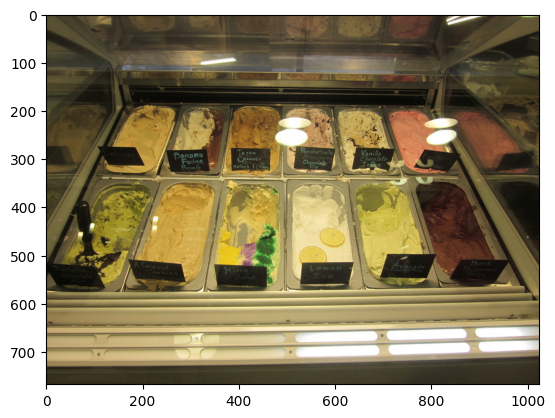

In [6]:
def display_image(image, print_info=True, hide_axis=False):
    if isinstance(image, str):
        img = Image.open(image)
        plt.imshow(img)
    elif isinstance(image, np.ndarray):
        image = image[..., ::-1] if image.shape[-1] == 3 else image
        img = Image.fromarray(image)
        plt.imshow(img)
    else:
        raise ValueError("Unsupported image format")

    if print_info:
        print("Type:", type(img))
        print("Shape:", np.array(img).shape)

    if hide_axis:
        plt.axis("off")

    plt.show()


train_images_dir = os.path.join(CFG.CUSTOM_DATASET_DIR, "train", "images")
example_image_path = sorted(
    [
        os.path.join(train_images_dir, f)
        for f in os.listdir(train_images_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
)[0]

print("Example:", example_image_path)
display_image(example_image_path, print_info=True, hide_axis=False)


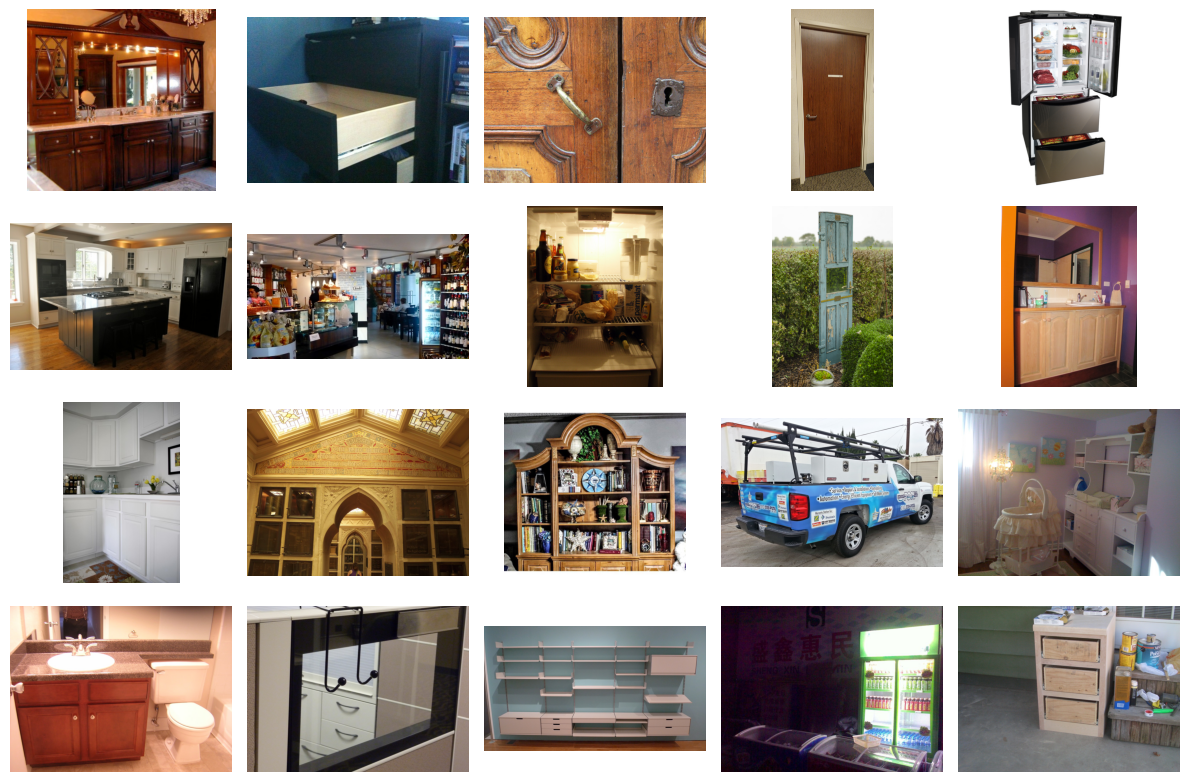

In [7]:
def plot_random_images_from_folder(folder_path, num_images=20, seed=CFG.SEED):
    random.seed(seed)
    image_files = [
        f for f in os.listdir(folder_path) if f.lower().endswith((".jpg", ".png", ".jpeg"))
    ]
    if len(image_files) < num_images:
        raise ValueError("Not enough images in the folder")

    selected_files = random.sample(image_files, num_images)
    num_cols = 5
    num_rows = (num_images + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 8))

    for i, file_name in enumerate(selected_files):
        img = Image.open(os.path.join(folder_path, file_name))
        ax = axes[i % num_cols] if num_rows == 1 else axes[i // num_cols, i % num_cols]
        ax.imshow(img)
        ax.axis("off")

    for i in range(num_images, num_rows * num_cols):
        ax = axes[i % num_cols] if num_rows == 1 else axes[i // num_cols, i % num_cols]
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()


plot_random_images_from_folder(train_images_dir, num_images=20)


In [8]:
def get_image_properties(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Could not read image file")
    return {
        "width": img.shape[1],
        "height": img.shape[0],
        "channels": img.shape[2] if len(img.shape) == 3 else 1,
        "dtype": img.dtype,
    }


img_properties = get_image_properties(example_image_path)
img_properties


{'width': 1024, 'height': 768, 'channels': 3, 'dtype': dtype('uint8')}

Статистика датасету: кількість зображень і кількість bounding box по кожному класу.


In [9]:
class_idx = {str(i): CFG.CLASSES[i] for i in range(CFG.NUM_CLASSES_TO_TRAIN)}

class_stat = {}
data_len = {}
class_info = []
instance_info = []

for mode in ["train", "valid", "test"]:
    image_count = {CFG.CLASSES[i]: 0 for i in range(CFG.NUM_CLASSES_TO_TRAIN)}
    instance_count = {CFG.CLASSES[i]: 0 for i in range(CFG.NUM_CLASSES_TO_TRAIN)}

    labels_path = os.path.join(CFG.CUSTOM_DATASET_DIR, mode, "labels")
    label_files = [f for f in os.listdir(labels_path) if f.endswith(".txt")]

    for file in label_files:
        with open(os.path.join(labels_path, file)) as f:
            lines = [line.strip() for line in f if line.strip()]

        classes_in_image = set()
        for line in lines:
            cls_id = line.split()[0]
            if cls_id not in class_idx:
                continue
            instance_count[class_idx[cls_id]] += 1
            classes_in_image.add(cls_id)

        for cls_id in classes_in_image:
            image_count[class_idx[cls_id]] += 1

    data_len[mode] = len(label_files)
    class_stat[mode] = instance_count
    class_info.append({"Mode": mode, **image_count, "Data_Volume": data_len[mode]})
    instance_info.append({"Mode": mode, **instance_count, "Boxes": sum(instance_count.values())})

print("Кількість зображень, у яких зустрічається клас:")
dataset_stats_df = pd.DataFrame(class_info)
with pd.option_context("display.max_columns", None):
    display(dataset_stats_df)

print("\nКількість bounding box (інстансів) по класах:")
instance_stats_df = pd.DataFrame(instance_info)
with pd.option_context("display.max_columns", None):
    display(instance_stats_df)


Кількість зображень, у яких зустрічається клас:


,Mode,door,cabinetDoor,refrigeratorDoor,window,chair,table,cabinet,couch,openedDoor,pole,Data_Volume
0,train,309,448,332,187,105,165,138,22,68,14,1008
1,valid,63,99,85,39,24,30,28,1,13,4,230
2,test,25,42,1,49,38,41,44,31,18,3,104



Кількість bounding box (інстансів) по класах:


,Mode,door,cabinetDoor,refrigeratorDoor,window,chair,table,cabinet,couch,openedDoor,pole,Boxes
0,train,479,3178,689,403,204,228,179,27,78,27,5492
1,valid,97,765,192,91,49,40,32,1,13,9,1289
2,test,34,179,2,63,87,47,52,58,20,8,550


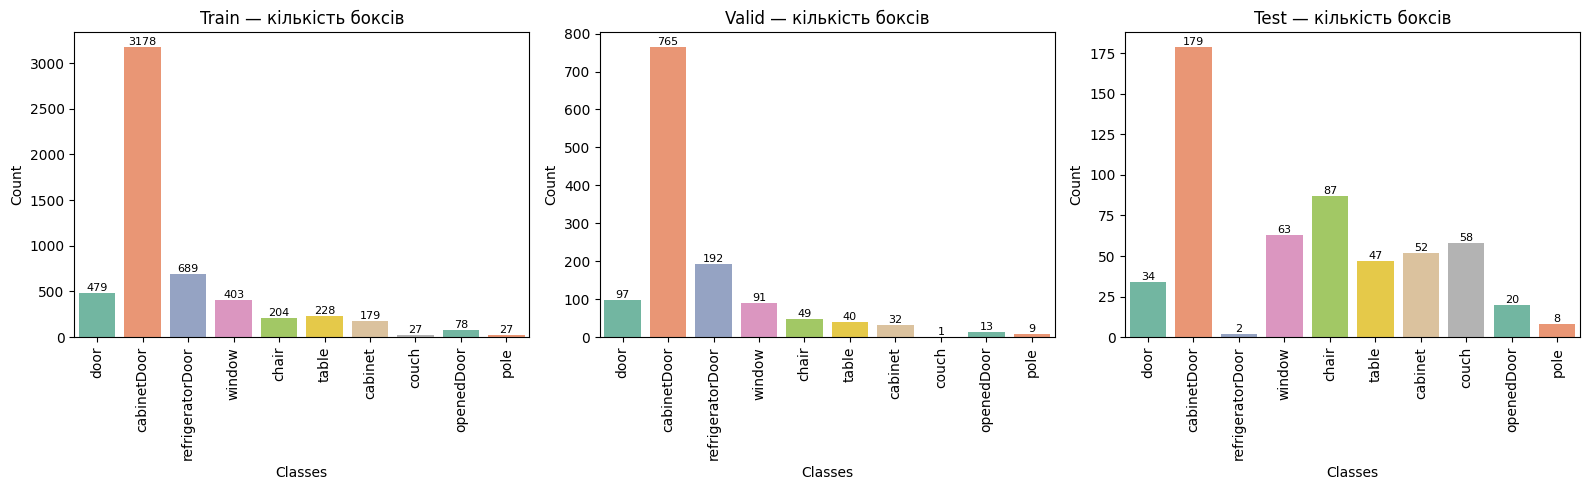

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, mode in enumerate(["train", "valid", "test"]):
    plot_df = instance_stats_df[instance_stats_df["Mode"] == mode].drop(columns=["Mode", "Boxes"])
    sns.barplot(data=plot_df, orient="v", ax=axes[i], palette="Set2")
    axes[i].set_title(f"{mode.capitalize()} — кількість боксів")
    axes[i].set_xlabel("Classes")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=90)
    for p in axes[i].patches:
        axes[i].annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8,
            color="black",
        )

plt.tight_layout()
plt.show()


Візуалізація ground-truth bounding box (YOLO-розмітка).


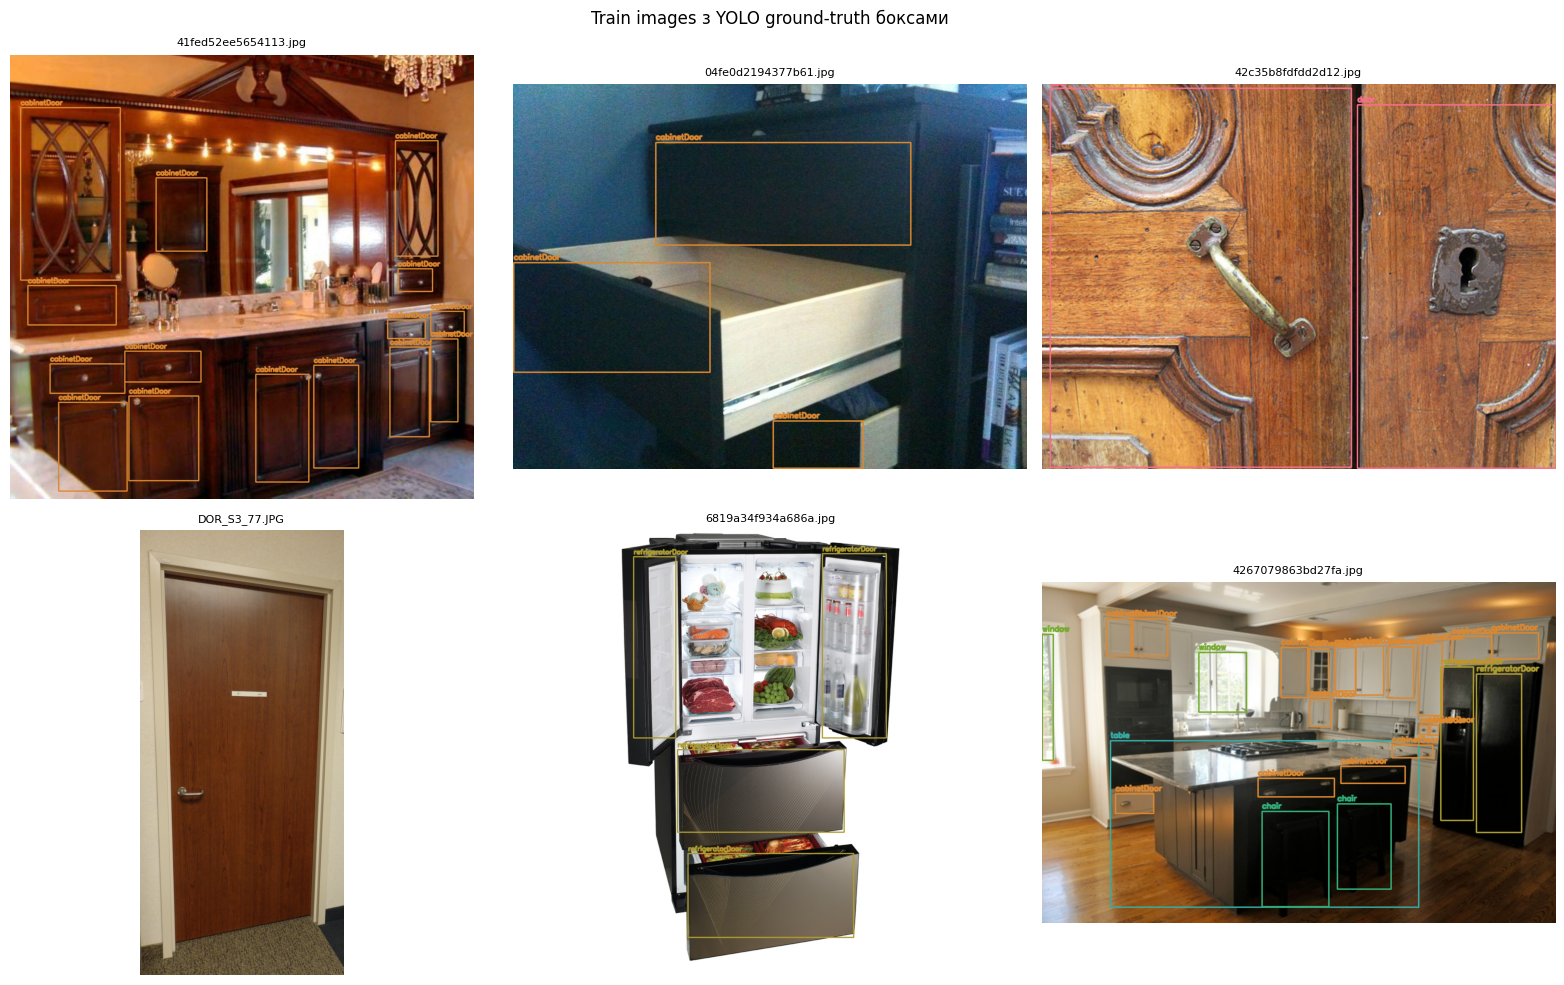

In [11]:
def yolo_label_path(image_path):
    labels_dir = os.path.dirname(image_path).replace(os.sep + "images", os.sep + "labels")
    stem = os.path.splitext(os.path.basename(image_path))[0]
    return os.path.join(labels_dir, stem + ".txt")


def draw_yolo_labels(image_path, class_names=CFG.CLASSES):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read {image_path}")
    h, w = img.shape[:2]
    colors = sns.color_palette("husl", len(class_names))
    label_path = yolo_label_path(image_path)

    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = [line.strip() for line in f if line.strip()]
        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                continue
            cls_id = int(float(parts[0]))
            cx, cy, bw, bh = map(float, parts[1:5])
            x1 = int((cx - bw / 2) * w)
            y1 = int((cy - bh / 2) * h)
            x2 = int((cx + bw / 2) * w)
            y2 = int((cy + bh / 2) * h)
            rgb = colors[cls_id % len(colors)]
            color = (int(rgb[2] * 255), int(rgb[1] * 255), int(rgb[0] * 255))
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            name = class_names[cls_id] if 0 <= cls_id < len(class_names) else str(cls_id)
            cv2.putText(
                img,
                name,
                (x1, max(0, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                color,
                2,
                cv2.LINE_AA,
            )
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


random.seed(CFG.SEED)
sample_images = random.sample(
    [
        os.path.join(train_images_dir, f)
        for f in os.listdir(train_images_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ],
    6,
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, path in zip(axes.ravel(), sample_images):
    ax.imshow(draw_yolo_labels(path))
    ax.set_title(os.path.basename(path)[:40], fontsize=8)
    ax.axis("off")
plt.suptitle("Train images з YOLO ground-truth боксами")
plt.tight_layout()
plt.show()


## Навчання YOLOv9s

Архітектура: **YOLOv9s** (pretrained COCO weights). Dual GPU: `device=[0, 1]` (T4 x2).

[Аргументи train](https://docs.ultralytics.com/modes/train/#arguments)


In [12]:
print("Model:", CFG.BASE_MODEL_WEIGHTS)
print("Epochs:", CFG.EPOCHS)
print("Batch:", CFG.BATCH_SIZE)
print("Imgsz:", CFG.IMGSZ)
print("Device:", CFG.DEVICE)
print("Fraction:", CFG.FRACTION)

model = YOLO(CFG.BASE_MODEL_WEIGHTS)


Model: yolov9s.pt
Epochs: 50
Batch: 32
Imgsz: 640
Device: [0, 1]
Fraction: 1.0


In [13]:
%%time

model.train(
    data=os.path.join(CFG.OUTPUT_DIR, "data.yaml"),
    task="detect",
    imgsz=CFG.IMGSZ,
    epochs=CFG.EPOCHS,
    batch=CFG.BATCH_SIZE,
    optimizer=CFG.OPTIMIZER,
    lr0=CFG.LR,
    lrf=CFG.LR_FACTOR,
    weight_decay=CFG.WEIGHT_DECAY,
    dropout=CFG.DROPOUT,
    fraction=CFG.FRACTION,
    patience=CFG.PATIENCE,
    profile=CFG.PROFILE,
    label_smoothing=CFG.LABEL_SMOOTHING,
    name=f"{CFG.BASE_MODEL}_{CFG.EXP_NAME}",
    seed=CFG.SEED,
    val=True,
    amp=True,
    exist_ok=True,
    resume=False,
    device=CFG.DEVICE,
    verbose=False,
    workers=4,
    plots=True,
)


WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.135 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, 

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      5.88G      1.476      1.932      1.455        177        640: 100% ━━━━━━━━━━━━ 32/32 2.4it/s 13.3s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.0it/s 1.3s0.5s
                   all        230       1289      0.458        0.3      0.241      0.132

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      5.88G      1.494      1.715      1.449         65        640: 100% ━━━━━━━━━━━━ 32/32 2.4it/s 13.1s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.1it/s 1.3s0.5s
                   all        230       1289      0.331      0.372      0.224       0.12

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      5.88G      1.484      1.739      1.438        107        640: 100% ━

{'metrics/precision(B)': 0.50553,
 'metrics/recall(B)': 0.48803,
 'metrics/mAP50(B)': 0.49861,
 'metrics/mAP50-95(B)': 0.343,
 'val/box_loss': 1.36357,
 'val/cls_loss': 1.23502,
 'val/dfl_loss': 1.49578,
 'fitness': 0.343}

Збереження ваг навченої моделі.


In [14]:
run_dir = os.path.join(CFG.OUTPUT_DIR, "runs", "detect", f"{CFG.BASE_MODEL}_{CFG.EXP_NAME}")
best_src = os.path.join(run_dir, "weights", "best.pt")
last_src = os.path.join(run_dir, "weights", "last.pt")

if os.path.exists(best_src):
    shutil.copy(best_src, os.path.join(CFG.OUTPUT_DIR, "best.pt"))
    print("Saved:", os.path.join(CFG.OUTPUT_DIR, "best.pt"))
else:
    print("best.pt not found:", best_src)

if os.path.exists(last_src):
    shutil.copy(last_src, os.path.join(CFG.OUTPUT_DIR, "last.pt"))
    print("Saved:", os.path.join(CFG.OUTPUT_DIR, "last.pt"))

print("Run dir:", run_dir)
print("Exists:", os.path.isdir(run_dir))


Saved: /kaggle/working/best.pt
Saved: /kaggle/working/last.pt
Run dir: /kaggle/working/runs/detect/yolov9s_indoor_50_epochs
Exists: True


## Аналіз результатів

Нижче — графіки навчання, метрики по класах і confusion matrix. Інтерпретація — у розділі «Висновки» в кінці ноутбука.

**Loss у YOLO:** box loss (координати боксів), cls loss (клас), dfl loss (Distribution Focal Loss / objectness).


In [15]:
results_paths = [
    i
    for i in glob.glob(os.path.join(run_dir, "*.png")) + glob.glob(os.path.join(run_dir, "*.jpg"))
    if "batch" not in os.path.basename(i)
]
results_paths


['/kaggle/working/runs/detect/yolov9s_indoor_50_epochs/confusion_matrix_normalized.png',
 '/kaggle/working/runs/detect/yolov9s_indoor_50_epochs/results.png',
 '/kaggle/working/runs/detect/yolov9s_indoor_50_epochs/BoxPR_curve.png',
 '/kaggle/working/runs/detect/yolov9s_indoor_50_epochs/BoxP_curve.png',
 '/kaggle/working/runs/detect/yolov9s_indoor_50_epochs/confusion_matrix.png',
 '/kaggle/working/runs/detect/yolov9s_indoor_50_epochs/BoxR_curve.png',
 '/kaggle/working/runs/detect/yolov9s_indoor_50_epochs/BoxF1_curve.png',
 '/kaggle/working/runs/detect/yolov9s_indoor_50_epochs/labels.jpg']

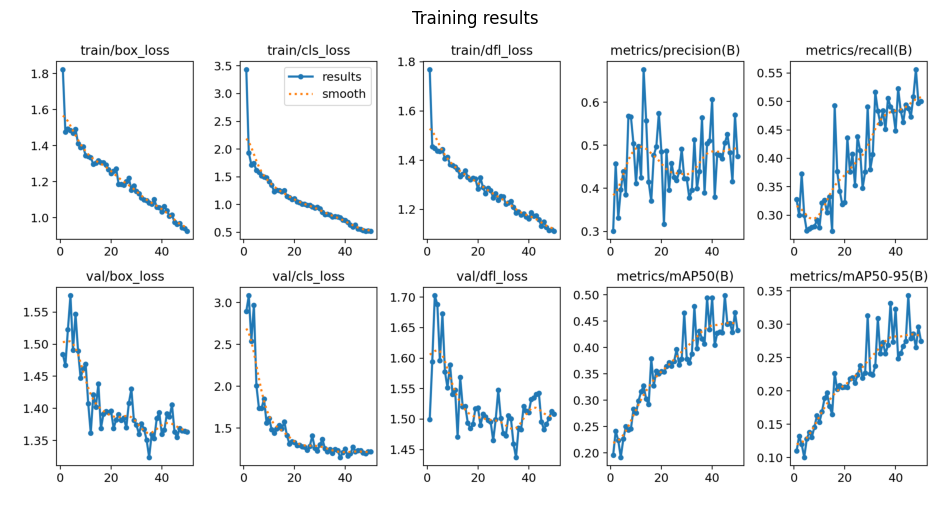

Missing: /kaggle/working/runs/detect/yolov9s_indoor_50_epochs/F1_curve.png
Missing: /kaggle/working/runs/detect/yolov9s_indoor_50_epochs/PR_curve.png
Missing: /kaggle/working/runs/detect/yolov9s_indoor_50_epochs/P_curve.png
Missing: /kaggle/working/runs/detect/yolov9s_indoor_50_epochs/R_curve.png


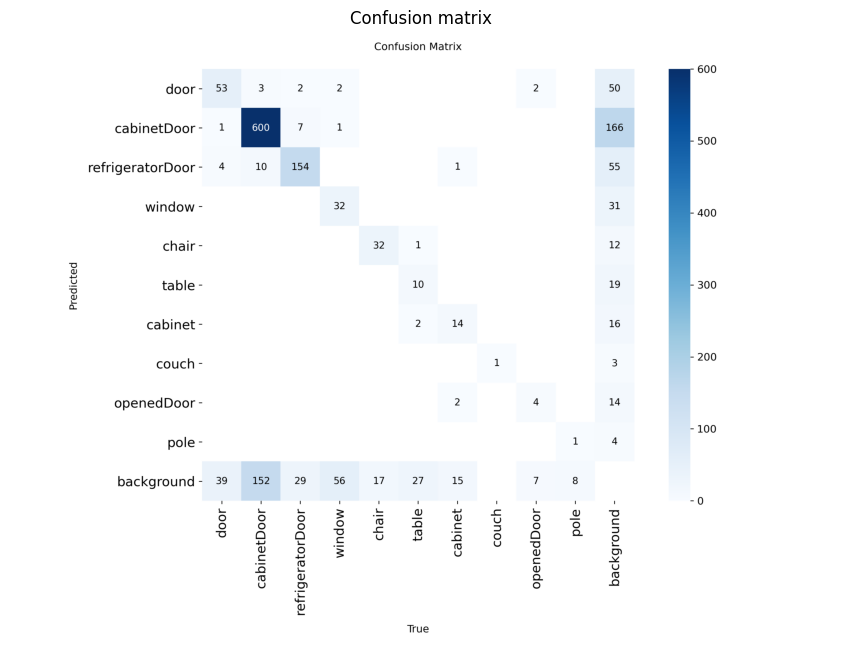

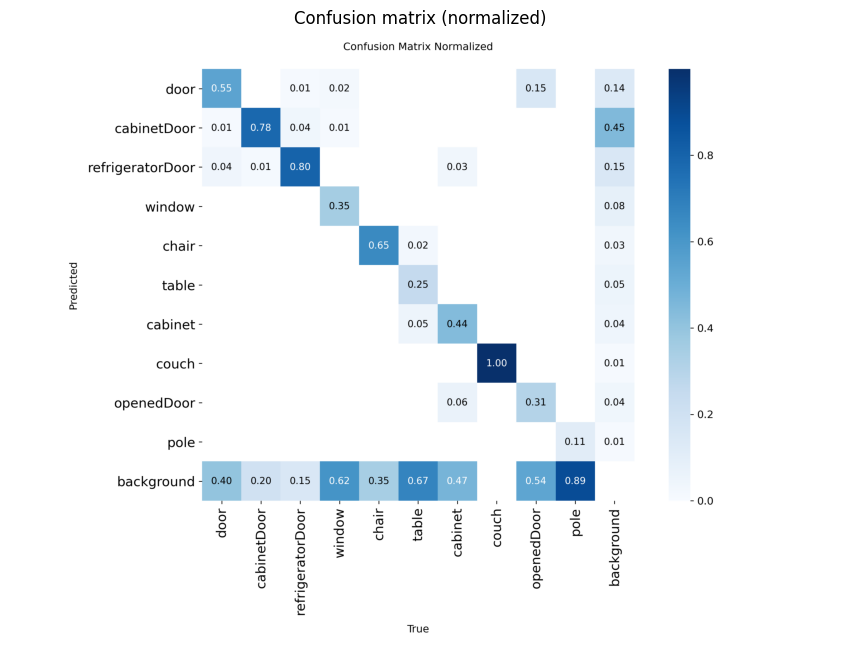

In [16]:
def show_result_image(filename, title=None):
    path = os.path.join(run_dir, filename)
    if not os.path.exists(path):
        print("Missing:", path)
        return
    plt.figure(figsize=(12, 8))
    plt.imshow(Image.open(path))
    plt.axis("off")
    plt.title(title or filename)
    plt.show()


for fname, title in [
    ("results.png", "Training results"),
    ("F1_curve.png", "F1-confidence"),
    ("PR_curve.png", "Precision-Recall"),
    ("P_curve.png", "Precision-confidence"),
    ("R_curve.png", "Recall-confidence"),
    ("confusion_matrix.png", "Confusion matrix"),
    ("confusion_matrix_normalized.png", "Confusion matrix (normalized)"),
]:
    show_result_image(fname, title)


In [17]:
df = pd.read_csv(os.path.join(run_dir, "results.csv"))
df = df.rename(columns=lambda x: x.replace(" ", ""))
df.to_csv(os.path.join(CFG.OUTPUT_DIR, "training_log_df.csv"), index=False)
df.tail()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
45,46,726.007,0.96314,0.55105,1.14913,0.52552,0.47314,0.44449,0.27866,1.35459,1.23454,1.48296,0.000078,0.000078,0.000078
46,47,741.610,0.96865,0.53328,1.12729,0.48361,0.50795,0.44571,0.28576,1.36847,1.20400,1.49155,0.000064,0.000064,0.000064
47,48,757.089,0.94378,0.51792,1.11533,0.41577,0.55628,0.42854,0.26525,1.36511,1.19420,1.50141,0.000050,0.000050,0.000050
48,49,772.707,0.94083,0.52791,1.11789,0.57096,0.49690,0.46646,0.29576,1.36440,1.22052,1.51253,0.000035,0.000035,0.000035
49,50,788.040,0.92509,0.51741,1.11144,0.47422,0.50004,0.43248,0.27443,1.36320,1.21736,1.50820,0.000021,0.000021,0.000021


In [18]:
print("*" * 50)
print("\nBest Training Box loss:", df["train/box_loss"].min(), ", on epoch:", df["train/box_loss"].argmin() + 1)
print("Best Validation Box loss:", df["val/box_loss"].min(), ", on epoch:", df["val/box_loss"].argmin() + 1)
print("=" * 50)
print("\nBest Training Cls loss:", df["train/cls_loss"].min(), ", on epoch:", df["train/cls_loss"].argmin() + 1)
print("Best Validation Cls loss:", df["val/cls_loss"].min(), ", on epoch:", df["val/cls_loss"].argmin() + 1)
print("=" * 50)
print("\nBest Training DFL loss:", df["train/dfl_loss"].min(), ", on epoch:", df["train/dfl_loss"].argmin() + 1)
print("Best Validation DFL loss:", df["val/dfl_loss"].min(), ", on epoch:", df["val/dfl_loss"].argmin() + 1)

map_col = "metrics/mAP50(B)"
map95_col = "metrics/mAP50-95(B)"
if map_col in df.columns:
    print("=" * 50)
    print("\nBest mAP50:", df[map_col].max(), ", on epoch:", df[map_col].argmax() + 1)
    print("Best mAP50-95:", df[map95_col].max(), ", on epoch:", df[map95_col].argmax() + 1)


**************************************************

Best Training Box loss: 0.92509 , on epoch: 50
Best Validation Box loss: 1.32364 , on epoch: 35

Best Training Cls loss: 0.51741 , on epoch: 50
Best Validation Cls loss: 1.15136 , on epoch: 38

Best Training DFL loss: 1.11144 , on epoch: 50
Best Validation DFL loss: 1.43725 , on epoch: 35

Best mAP50: 0.49861 , on epoch: 45
Best mAP50-95: 0.343 , on epoch: 45


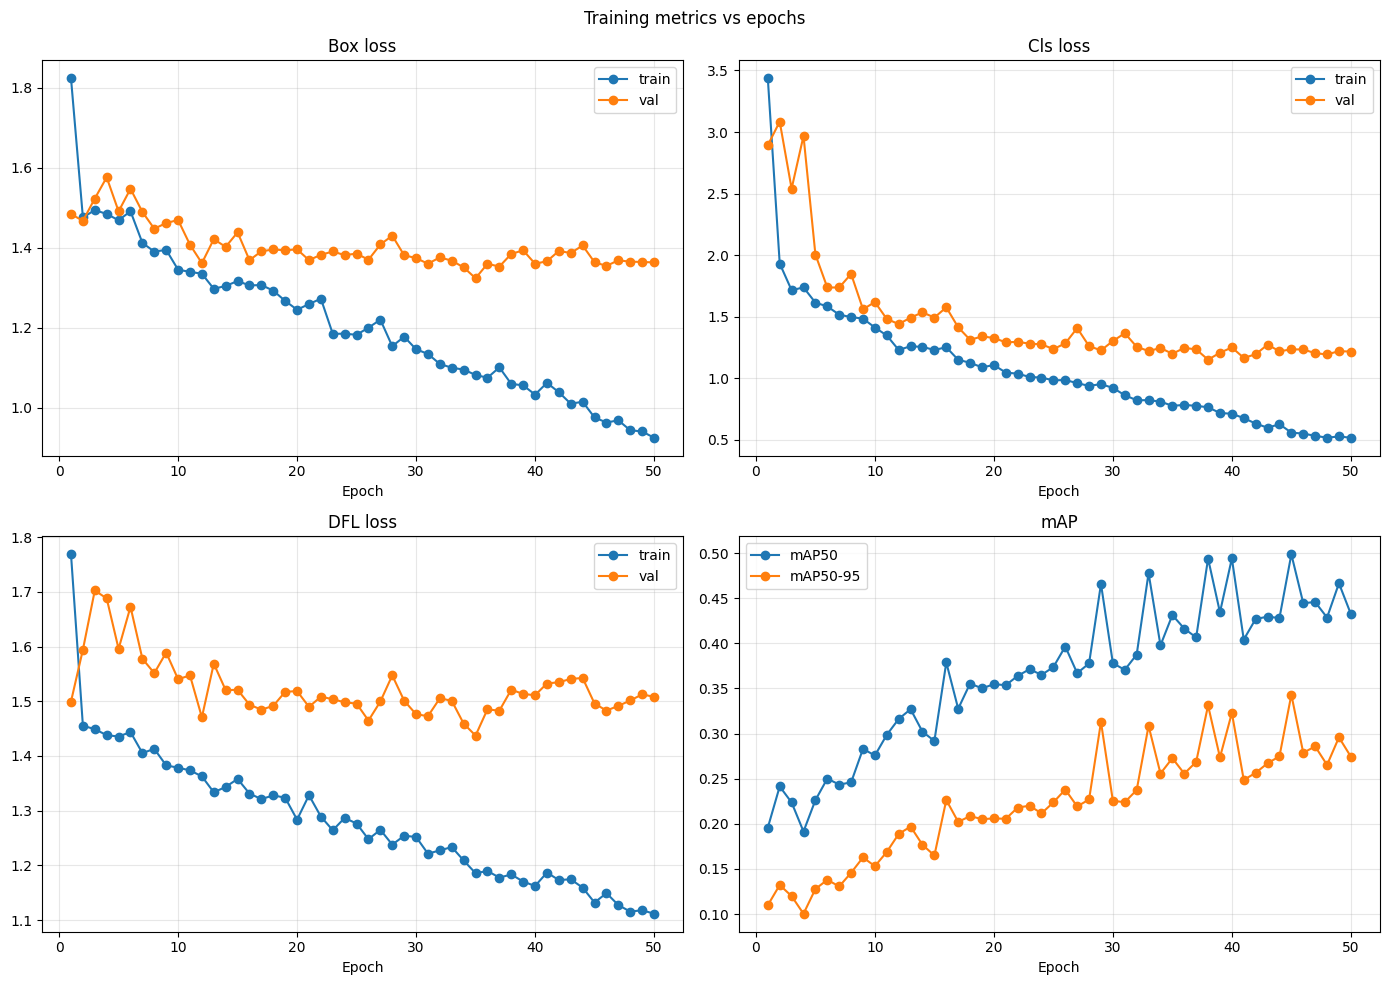

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(df["epoch"], df["train/box_loss"], marker="o", label="train")
axes[0, 0].plot(df["epoch"], df["val/box_loss"], marker="o", label="val")
axes[0, 0].set_title("Box loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(df["epoch"], df["train/cls_loss"], marker="o", label="train")
axes[0, 1].plot(df["epoch"], df["val/cls_loss"], marker="o", label="val")
axes[0, 1].set_title("Cls loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(df["epoch"], df["train/dfl_loss"], marker="o", label="train")
axes[1, 0].plot(df["epoch"], df["val/dfl_loss"], marker="o", label="val")
axes[1, 0].set_title("DFL loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(df["epoch"], df["metrics/mAP50(B)"], marker="o", label="mAP50")
axes[1, 1].plot(df["epoch"], df["metrics/mAP50-95(B)"], marker="o", label="mAP50-95")
axes[1, 1].set_title("mAP")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Training metrics vs epochs")
plt.tight_layout()
plt.show()


Метрики по кожному класу (validation) і оцінка на test split.


In [20]:
best_model = YOLO(os.path.join(CFG.OUTPUT_DIR, "best.pt"))

val_metrics = best_model.val(
    data=os.path.join(CFG.OUTPUT_DIR, "data.yaml"),
    split="val",
    imgsz=CFG.IMGSZ,
    device=CFG.DEVICE,
    plots=True,
    verbose=True,
)


def per_class_table(metrics, class_names):
    nc = len(class_names)
    p = np.full(nc, np.nan)
    r = np.full(nc, np.nan)
    ap50 = np.full(nc, np.nan)
    ap = np.full(nc, np.nan)

    idx = np.array(getattr(metrics.box, "ap_class_index", np.arange(nc))).reshape(-1)
    p_raw = np.array(metrics.box.p, dtype=float).reshape(-1)
    r_raw = np.array(metrics.box.r, dtype=float).reshape(-1)
    ap50_raw = np.array(metrics.box.ap50, dtype=float).reshape(-1)
    maps = np.array(metrics.box.maps, dtype=float).reshape(-1)

    for j, c in enumerate(idx):
        c = int(c)
        if c >= nc:
            continue
        if j < len(p_raw):
            p[c] = p_raw[j]
        if j < len(r_raw):
            r[c] = r_raw[j]
        if j < len(ap50_raw):
            ap50[c] = ap50_raw[j]
    if len(maps) == nc:
        ap = maps

    rows = []
    for i, name in enumerate(class_names):
        pi, ri = p[i], r[i]
        f1 = 2 * pi * ri / (pi + ri) if np.isfinite(pi) and np.isfinite(ri) and (pi + ri) else np.nan
        rows.append(
            {
                "class": name,
                "precision": pi,
                "recall": ri,
                "f1": f1,
                "AP50": ap50[i],
                "AP50-95": ap[i],
            }
        )
    return pd.DataFrame(rows)


per_class_df = per_class_table(val_metrics, CFG.CLASSES)
per_class_df = per_class_df.sort_values("f1", ascending=False).reset_index(drop=True)
display(per_class_df.round(4))

print("\nOverall val:")
print(val_metrics.results_dict)


Ultralytics 8.4.135 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
YOLOv9s summary (fused): 197 layers, 7,170,958 parameters, 0 gradients, 26.7 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.8 ms, read: 439.0±330.0 MB/s, size: 272.4 KB)
val: Scanning /kaggle/input/datasets/thepbordin/indoor-object-detection/valid/labels... 230 images, 31 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 230/230 1.1Kit/s 0.2s<0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/thepbordin/indoor-object-detection/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 3.5it/s 4.3s0.2s
                   all        230       1289      0.507      0.483      0.497      0.343
                  door         63         97      0.545      0.493      0.504      0.312
           cabinetDoor         99        765      0.8

,class,precision,recall,f1,AP50,AP50-95
0,cabinetDoor,0.8291,0.7542,0.7899,0.7983,0.4563
1,refrigeratorDoor,0.7389,0.7656,0.7520,0.8111,0.5547
2,chair,0.7042,0.5830,0.6379,0.6486,0.4035
3,door,0.5445,0.4931,0.5175,0.5038,0.3117
4,cabinet,0.5841,0.4375,0.5003,0.3921,0.2808
5,window,0.5581,0.3054,0.3948,0.3281,0.2043
6,couch,0.2318,1.0000,0.3764,0.9950,0.9950
7,openedDoor,0.2519,0.2308,0.2409,0.1384,0.0548
8,table,0.3224,0.1500,0.2047,0.2245,0.1138
9,pole,0.3026,0.1111,0.1625,0.1297,0.0512



Overall val:
{'metrics/precision(B)': 0.506762977043173, 'metrics/recall(B)': 0.4830748097607054, 'metrics/mAP50(B)': 0.49696120912352226, 'metrics/mAP50-95(B)': 0.3426026979460505, 'fitness': 0.3426026979460505}


In [21]:
test_metrics = best_model.val(
    data=os.path.join(CFG.OUTPUT_DIR, "data.yaml"),
    split="test",
    imgsz=CFG.IMGSZ,
    device=CFG.DEVICE,
    plots=True,
    verbose=True,
)

test_per_class_df = per_class_table(test_metrics, CFG.CLASSES)
test_per_class_df = test_per_class_df.sort_values("f1", ascending=False).reset_index(drop=True)
print("Test — метрики по класах:")
display(test_per_class_df.round(4))
print("\nOverall test:")
print(test_metrics.results_dict)


Ultralytics 8.4.135 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 69.7±16.3 MB/s, size: 363.5 KB)
val: Scanning /kaggle/input/datasets/thepbordin/indoor-object-detection/test/labels... 104 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 107/107 315.0it/s 0.3s.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/thepbordin/indoor-object-detection/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.9it/s 2.4s0.3ss
                   all        107        550       0.46      0.323      0.364      0.213
                  door         25         34      0.404      0.235      0.233      0.118
           cabinetDoor         42        179      0.677      0.486      0.512      0.195
      refrigeratorDoor          1          2       0.56

,class,precision,recall,f1,AP50,AP50-95
0,refrigeratorDoor,0.5602,1.0000,0.7181,0.9950,0.7460
1,cabinetDoor,0.6766,0.4860,0.5657,0.5124,0.1946
2,window,0.6872,0.4603,0.5513,0.5060,0.3115
3,chair,0.6633,0.3678,0.4732,0.4051,0.2081
4,table,0.6292,0.2168,0.3225,0.3056,0.1729
5,couch,0.4283,0.2414,0.3087,0.2270,0.1129
6,door,0.4041,0.2353,0.2974,0.2329,0.1176
7,cabinet,0.3889,0.1731,0.2395,0.2291,0.1478
8,openedDoor,0.1648,0.0500,0.0767,0.1231,0.0587
9,pole,0.0000,0.0000,NaN,0.1084,0.0594



Overall test:
{'metrics/precision(B)': 0.46026290129437697, 'metrics/recall(B)': 0.3230710815439063, 'metrics/mAP50(B)': 0.3644492287657057, 'metrics/mAP50-95(B)': 0.21294745330199352, 'fitness': 0.21294745330199352}


Приклади validation batch: labels vs predictions.


In [ ]:
validation_results_paths = [
    i
    for i in glob.glob(os.path.join(run_dir, "*.png")) + glob.glob(os.path.join(run_dir, "*.jpg"))
    if "val_batch" in os.path.basename(i)
]
print("Val batch files:", len(validation_results_paths))
for path in sorted(validation_results_paths):
    print(path)
    plt.figure(figsize=(14, 8))
    plt.imshow(Image.open(path))
    plt.axis("off")
    plt.title(os.path.basename(path))
    plt.show()


## Висновки

Модель: **YOLOv9s**, 50 епох, batch 32, imgsz 640, GPU T4 x2. Навчання зайняло ~14 хвилин. `best.pt` відповідає епосі **45**.

### 1. Криві навчання (overfitting / underfitting)

- Train box/cls/dfl loss монотонно знижуються до кінця (найкращі train loss на епосі 50: box 0.925, cls 0.517, dfl 1.111). Val loss виходить на плато раніше: найкращий val box/dfl на епосі **35**, val cls на епосі **38**. Після цього train ще падає, а val ні — помірний overfitting.
- mAP нестабільний по епохах (типово для малого й незбалансованого датасету). Пік: **mAP50 = 0.499, mAP50-95 = 0.343** на епосі 45. На епосі 50 метрики гірші (mAP50 0.432) — Ultralytics коректно зберіг `best.pt` не з останньої епохи.
- Early stopping (patience=15) не спрацював: 50 епох пройшли повністю. Додаткові епохи без змін даних/регуляризації навряд чи допоможуть.

### 2. Загальні метрики vs орієнтир ДЗ

Орієнтир ДЗ: mAP@0.5 ≈ 40–60%, mAP@0.5:0.95 ≈ 25–40%, F1 ≈ 45–60%.

| split | Precision | Recall | mAP50 | mAP50-95 | macro F1 |
|-------|-----------|--------|-------|----------|----------|
| val (best.pt) | 0.507 | 0.483 | **0.497** | **0.343** | ~0.46 |
| test | 0.460 | 0.323 | **0.364** | 0.213 | ~0.36 |

- **Val** потрапляє в орієнтир по mAP50 і mAP50-95, F1 — біля нижньої межі.
- **Test** нижчий: mAP50 трохи під орієнтиром (36% vs 40%), mAP50-95 і recall просідають. Причина — зсув розподілу між val і test, а не лише якість моделі (див. нижче).
- Мета ДЗ «виявляти хоча б ~1/3 класів, зокрема двері / стільці / столи»:
  - val AP50 ≥ 0.33: refrigeratorDoor, cabinetDoor, chair, door, cabinet (**5/10** класів);
  - door (val AP50 0.50) і chair (0.65) працюють прийнятно; table слабкий (val 0.22, test 0.31);
  - на test стійко детектуються cabinetDoor, window, chair. **Базова функціональність є**, але door/table на test ще нестабільні.

### 3. Продуктивність по класах

**Val (надійніше, бо більше інстансів):**

- Найкращі: **cabinetDoor** (P 0.83, R 0.75, F1 0.79, AP50 0.80), **refrigeratorDoor** (F1 0.75, AP50 0.81), **chair** (F1 0.64, AP50 0.65), **door** (F1 0.52, AP50 0.50).
- Найгірші: **pole** (F1 0.16, AP50 0.13), **table** (F1 0.20, AP50 0.22), **openedDoor** (F1 0.24, AP50 0.14).
- **couch** на val: 1 зображення / 1 бокс, AP50 0.995 — метрика неінформативна.

**Test:**

- Відносно краще: cabinetDoor (F1 0.57), window (0.55), chair (0.47).
- Слабкі: openedDoor (F1 0.08), pole (P=R=0), door (F1 0.30).
- refrigeratorDoor на test: 1 зображення / 2 бокси, AP50 0.995 — теж неінформативно.

Причини:

- Сильний **класовий дисбаланс**. Train: cabinetDoor 3178 боксів vs pole/couch по 27, openedDoor 78. Модель «бачить» дверцята шаф набагато частіше за стовпи й відкриті двері.
- **Зсув розподілу val vs test.** refrigeratorDoor: 192 бокси на val і лише 2 на test; couch: 1 на val і 58 на test. Val переоцінює класи, яких багато в train/val, і недооцінює ті, що домінують у test.
- Візуальна схожість: door vs openedDoor, cabinet vs cabinetDoor, refrigeratorDoor vs cabinetDoor. Table часто частково закритий, pole — тонкий і рідкісний об'єкт.

### 4. Confusion matrix

За нормалізованою матрицею та per-class recall очікувані помилки:

- **door ↔ openedDoor** — той самий об'єкт у різних станах, мало прикладів openedDoor (78 train).
- **cabinetDoor ↔ refrigeratorDoor / cabinet** — прямокутні «дверцята» схожої геометрії.
- **table / chair** — меблі в одному кадрі, стіл часто частково перекритий.
- **pole** майже весь іде в background (FN): 4 val-зображення, 3 test-зображення.
- Багато FN (background) для рідкісних класів — модель пропускає об'єкт частіше, ніж плутає його з іншим класом (низький recall у table, openedDoor, pole).

### 5. Чи досягнуто мети і що покращити

Так, як робочий прототип: val mAP50 ≈ 50% у межах орієнтиру, більше ніж третина класів детектується, найпоширеніші дверцята/двері/стільці на val працюють. Ні, як фінальна система: test mAP50 36%, door/table/openedDoor/pole слабкі, є overfitting після ~35–45 епохи.

Конкретні кроки:

- **Дані:** дозбирати pole, openedDoor, couch, table; вирівняти розподіл train/val/test (зараз test не схожий на val). Перевірити розмітку door vs openedDoor.
- **Дисбаланс:** `cls` loss weight вище, copy-paste / mosaic з oversampling рідкісних класів, або class-aware sampling.
- **Регуляризація проти overfitting:** зупинятися ближче до епохи 35–45, збільшити augment (scale, mixup), трохи більший weight decay / label smoothing.
- **Архітектура:** YOLOv9c або YOLO11s, якщо залишиться GPU-бюджет; для дрібних об'єктів (pole, distant doors) — більший `imgsz` (1280) або P2-head.
- **Інференс:** підібрати conf/IoU по F1-кривій окремо для door/chair/table, а не один глобальний поріг.
